Total records loaded: 75612
      鄉鎮市區          交易標的               土地位置建物門牌 土地移轉總面積平方公尺   都市土地使用分區  \
10     萬華區     房地(土地+建物)     臺北市萬華區漢口街二段５１號九樓之５        6.39          商   
11     士林區     房地(土地+建物)      臺北市士林區延平北路五段５０號九樓       22.91          住   
15     中山區     房地(土地+建物)      臺北市中山區四平街１０７號六樓之１        9.35          住   
18     松山區     房地(土地+建物)       臺北市松山區復興北路１號八樓之３        14.6          商   
19     大同區     房地(土地+建物)  臺北市大同區民權西路１０２巷４弄２３號四樓        8.81          住   
...    ...           ...                    ...         ...        ...   
75603  中山區  房地(土地+建物)+車位     臺北市中山區植福路１９１之１號十一樓       19.34  都市：其他:娛樂區   
75604  中山區     房地(土地+建物)       臺北市中山區植福路１９３號十一樓       16.79  都市：其他:娛樂區   
75605  中山區  房地(土地+建物)+車位     臺北市中山區植福路１９５之１號十一樓       19.34  都市：其他:娛樂區   
75606  中山區  房地(土地+建物)+車位       臺北市中山區植福路１９１號十一樓       20.79  都市：其他:娛樂區   
75607  中山區  房地(土地+建物)+車位       臺北市中山區植福路１９５號十一樓       20.74  都市：其他:娛樂區   

      非都市土地使用分區 非都市土地使用編定    交易年月日      交易筆棟數 移轉層次  ...  陽台面積 電梯  移轉編號  \
10       

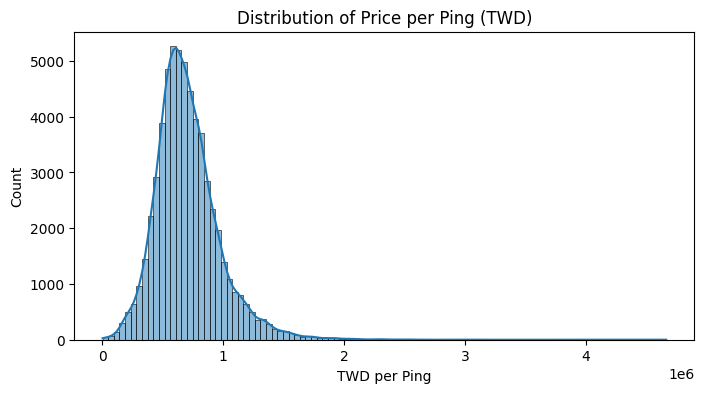

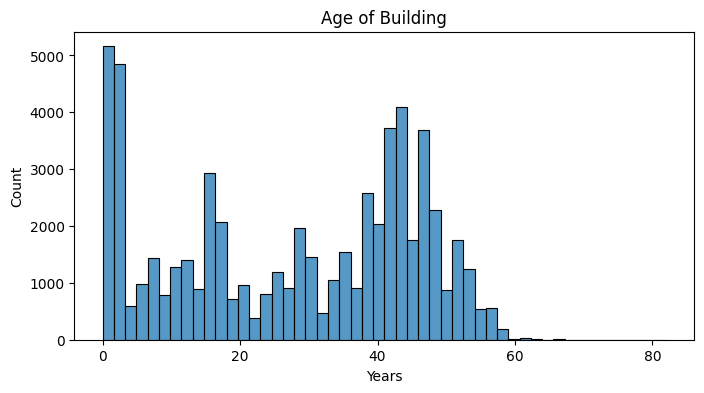

✅ Cleaned data saved to data/processed/cleaned_taipei.csv


In [1]:
# Filename: 01_data_cleaning_taipei.ipynb

# Jupyter Notebook (represented as script for now)

# --------------------
# 📦 1. Import libraries
# --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
import re

# --------------------
# 📁 2. Load raw CSVs (assumes files are in data/raw/ and cover 2021–2024)
# --------------------
files = sorted(glob('data/raw/*_A_lvr_land_A.csv'))  # Adjust pattern as needed

# Combine files for recent 3 years
dfs = []
for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"Total records loaded: {len(data)}")

# --------------------
# 🔍 3. Initial filtering for residential properties
# --------------------
# Keep only rows with building type indicating residential (e.g., "住宅大樓", "公寓")
res_keywords = ['住宅大樓', '公寓', '華廈']
data = data[data['建物型態'].astype(str).apply(lambda x: any(k in x for k in res_keywords))]

# Remove entries with missing or 0 area
data = data[pd.to_numeric(data['建物移轉總面積平方公尺'], errors='coerce') > 0]

# --------------------
# 🛠 4. Feature Engineering
# --------------------
chinese_numerals = {
    '零': 0, '一': 1, '二': 2, '兩': 2, '三': 3, '四': 4,
    '五': 5, '六': 6, '七': 7, '八': 8, '九': 9,
    '十': 10
}

def chinese_to_number(text):
    if not text:
        return None
    total = 0
    if '十' in text:
        parts = text.split('十')
        if parts[0] == '':
            total += 10
        else:
            total += chinese_numerals.get(parts[0], 0) * 10
        if len(parts) > 1 and parts[1]:
            total += chinese_numerals.get(parts[1], 0)
    else:
        total = chinese_numerals.get(text, 0)
    return total

def extract_floor(s):
    s = str(s).strip()
    match = re.search(r'(\d+)', s)
    if match:
        floor = int(match.group(1))
    else:
        chinese_match = re.search(r'([零一二兩三四五六七八九十]+)', s)
        if chinese_match:
            floor = chinese_to_number(chinese_match.group(1))
        else:
            return np.nan

    if 'B' in s.upper() or '地下' in s or '地下一' in s:
        floor = -abs(floor)
    return floor

# Transaction date parsing
def convert_roc_date(roc_date):
    try:
        roc_date = str(roc_date).zfill(7)
        year = int(roc_date[:3]) + 1911
        month = int(roc_date[3:5])
        day = int(roc_date[5:7])
        return pd.Timestamp(year=year, month=month, day=day)
    except:
        return pd.NaT 

data['交易日期'] = data['交易年月日'].apply(convert_roc_date)
data = data[data['交易日期'].notna()]
data['建築完成日期'] = data['建築完成年月'].apply(convert_roc_date)
data = data[data['建築完成日期'].notna()]

# Convert floor and building completion year to usable forms
data['樓層數'] = data['總樓層數'].apply(extract_floor)
data['建築完成日'] = data['建築完成年月'].apply(convert_roc_date)
reference_date = pd.Timestamp('2024-12-31')
data['屋齡'] = data['建築完成日'].apply(
    lambda d: (reference_date.year - d.year) - ((reference_date.month, reference_date.day) < (d.month, d.day)) if pd.notna(d) else None
)

# Area conversion: 平方公尺 → 坪 (1 坪 = 3.305785)
data['建物面積_坪'] = pd.to_numeric(data['建物移轉總面積平方公尺'], errors='coerce') / 3.305785

# Price per ping (normalized price)
data['單價_每坪'] = pd.to_numeric(data['總價元'], errors='coerce') / data['建物面積_坪']

# Remove unrealistic unit prices
data = data[(data['單價_每坪'] > 1000)]
print(data)

# --------------------
# 📊 5. Basic EDA
# --------------------
plt.figure(figsize=(8, 4))
sns.histplot(data['單價_每坪'].dropna(), bins=100, kde=True)
plt.title("Distribution of Price per Ping (TWD)")
plt.xlabel("TWD per Ping")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data['屋齡'].dropna(), bins=50)
plt.title("Age of Building")
plt.xlabel("Years")
plt.show()

# --------------------
# 💾 6. Save cleaned data
# --------------------
os.makedirs('data/processed', exist_ok=True)
data.to_csv('data/processed/cleaned_taipei.csv', index=False)

print("✅ Cleaned data saved to data/processed/cleaned_taipei.csv")

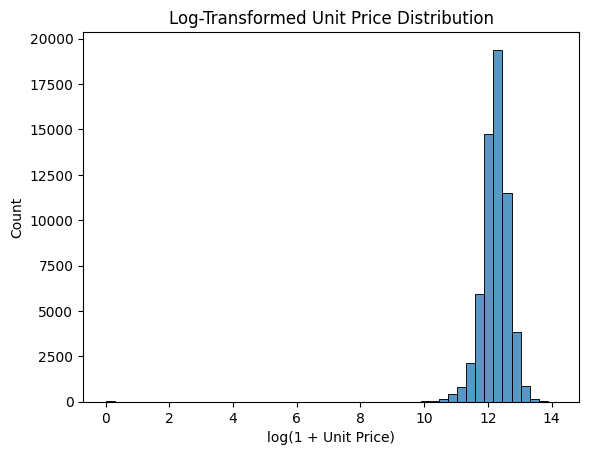

In [2]:
# EDA
data['單價元平方公尺'] = pd.to_numeric(data['單價元平方公尺'], errors='coerce')
data['log_unit_price'] = np.log1p(data['單價元平方公尺'])

sns.histplot(data['log_unit_price'].dropna(), bins=50)
plt.title("Log-Transformed Unit Price Distribution")
plt.xlabel("log(1 + Unit Price)")
plt.show()

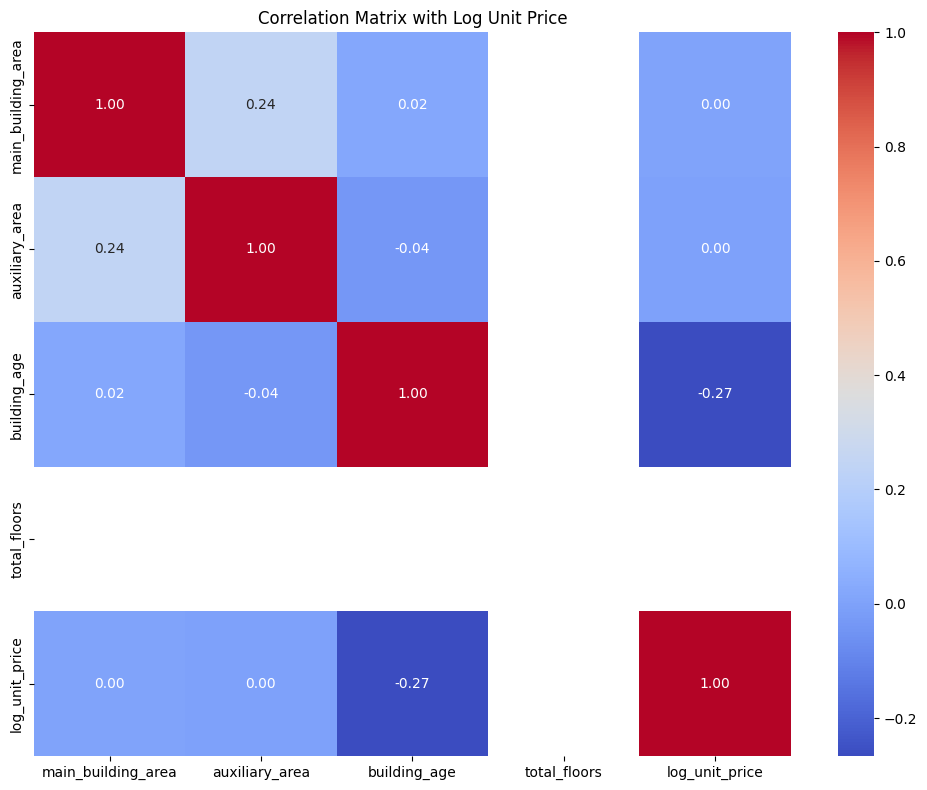

In [3]:
# Select numerical features likely related to price
data = data.rename(columns={
    '主建物面積': 'main_building_area',
    '附屬建物面積': 'auxiliary_area',
    '屋齡': 'building_age',
    '總樓層數': 'total_floors',
    '單價元平方公尺': 'unit_price',
    'log_unit_price': 'log_unit_price',
    '鄉鎮市區': 'district'
})
corr_cols = ['main_building_area', 'auxiliary_area', 'building_age', 'total_floors', 'log_unit_price']

# Ensure all selected columns are numeric
for col in corr_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Compute correlation matrix
corr = data[corr_cols].corr()

# Plot heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Correlation Matrix with Log Unit Price")
# plt.show()

# Plot and save heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix with Log Unit Price')
plt.tight_layout()
# plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


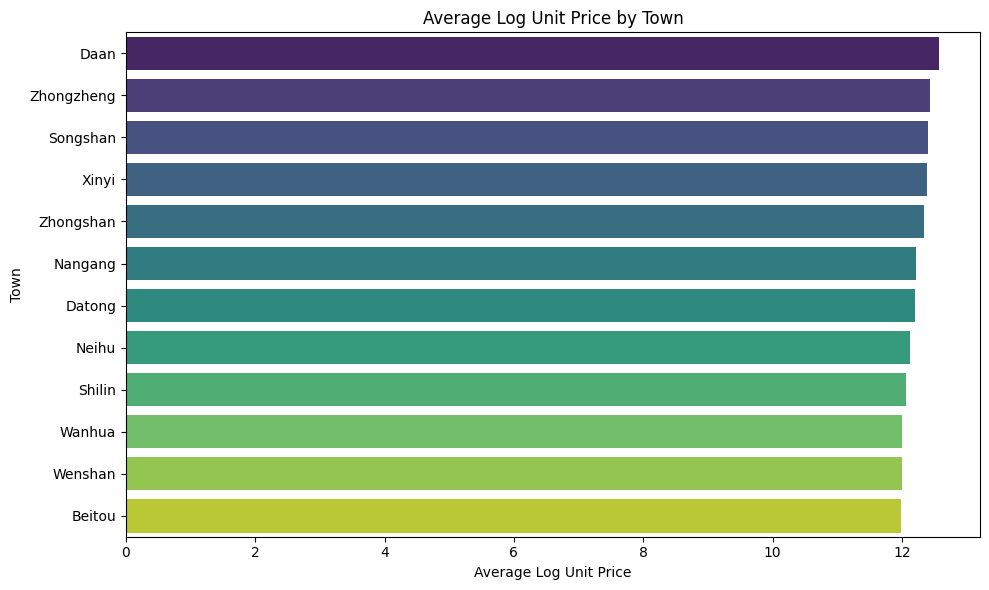

In [4]:
# Mapping of Taipei districts from Chinese to English
district_map = {
    '中正區': 'Zhongzheng',
    '大同區': 'Datong',
    '中山區': 'Zhongshan',
    '松山區': 'Songshan',
    '大安區': 'Daan',
    '萬華區': 'Wanhua',
    '信義區': 'Xinyi',
    '士林區': 'Shilin',
    '北投區': 'Beitou',
    '內湖區': 'Neihu',
    '南港區': 'Nangang',
    '文山區': 'Wenshan'
}

# Apply the mapping to the district column
data['district_en'] = data['district'].map(district_map)

# Group the data by 'town' and calculate the mean of log-transformed unit price
grouped = data.groupby('district_en')['log_unit_price'].mean().sort_values(ascending=False)

# Create a barplot to visualize average log unit price by town
plt.figure(figsize=(10, 6))
sns.barplot(x=grouped.values, y=grouped.index, hue=grouped.index, palette='viridis', legend=False)
plt.xlabel('Average Log Unit Price')
plt.ylabel('Town')
plt.title('Average Log Unit Price by Town')
plt.tight_layout()
plt.savefig('average_log_unit_price_by_town.png', dpi=300)
plt.show()

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# save mse
mse_list = []

for train_idx, val_idx in kf.split(data):
    train_data = data.iloc[train_idx].copy()
    val_data = data.iloc[val_idx].copy()

    # Target mean encoding
    district_means = train_data.groupby('district_en')['log_unit_price'].mean()
    train_data['district_encoded'] = train_data['district_en'].map(district_means)
    val_data['district_encoded'] = val_data['district_en'].map(district_means)

    # Replace unknown districts in validation set with global mean
    global_mean = train_data['log_unit_price'].mean()
    val_data['district_encoded'] = val_data['district_encoded'].fillna(global_mean)

    # Remove rows where target is NaN
    train_data = train_data.dropna(subset=['log_unit_price'])
    val_data = val_data.dropna(subset=['log_unit_price'])

    # Select features (you can add more features here if needed)
    # '主建物面積': 'main_building_area',
    # '附屬建物面積': 'auxiliary_area',
    # '屋齡': 'building_age',
    # '總樓層數': 'total_floors',
    # '單價元平方公尺': 'unit_price',
    feature_cols = ['district_encoded', 'building_age']
    X_train = train_data[feature_cols]
    X_val = val_data[feature_cols]
    y_train = train_data['log_unit_price']
    y_val = val_data['log_unit_price']

    # Fill any remaining NaN values
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_val_imputed = imputer.transform(X_val)

    # Train model
    model = LinearRegression()
    model.fit(X_train_imputed, y_train)

    # Predict and evaluate
    preds = model.predict(X_val_imputed)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mse_list.append(rmse)
    print(f"Validation RMSE: {rmse:.4f}")
    
print(f"Average RMSE across folds: {np.mean(mse_list):.4f}")

Validation RMSE: 0.5024
Validation RMSE: 0.4961
Validation RMSE: 0.4601
Validation RMSE: 0.4520
Validation RMSE: 0.5237
Average RMSE across folds: 0.4869


In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

# build encoded district
district_mean_price = data.groupby('district_en')['log_unit_price'].mean()
data['district_encoded'] = data['district_en'].map(district_mean_price)

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_list = []

for train_idx, val_idx in kf.split(data):
    train_data = data.iloc[train_idx].copy()
    val_data = data.iloc[val_idx].copy()

    # target mean encoding for validation (prevent from leaking data)
    district_means = train_data.groupby('district')['log_unit_price'].mean()
    train_data['district_encoded'] = train_data['district'].map(district_means)
    val_data['district_encoded'] = val_data['district'].map(district_means)
    global_mean = train_data['log_unit_price'].mean()
    val_data['district_encoded'] = val_data['district_encoded'].fillna(global_mean)

    # remove NaN in log_unit_price
    train_data = train_data.dropna(subset=['log_unit_price'])
    val_data = val_data.dropna(subset=['log_unit_price'])

    # choose feature
    feature_cols = ['district_encoded', 'building_age', 'main_building_area']
    X_train = train_data[feature_cols]
    X_val = val_data[feature_cols]
    y_train = train_data['log_unit_price']
    y_val = val_data['log_unit_price']

    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_val_imputed = imputer.transform(X_val)

    # build Random Forest model
    model = RandomForestRegressor(
        n_estimators=100, 
        max_depth = 10,
        random_state=42
    )
    model.fit(X_train_imputed, y_train)

    # predict and evaluate
    preds = model.predict(X_val_imputed)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_list.append(rmse)

print(f"Average RMSE across folds (Random Forest): {np.mean(rmse_list):.4f}")


Average RMSE across folds (Random Forest): 0.3648
